 1. Load Data

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('Temperature Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


 1.1 Data Quality Check

Before modeling, confirm there are no missing values and get a sense of each feature's scale — this matters because SVR and KNN are sensitive to features being on very different ranges.

In [2]:
print(df.isnull().sum())
print()
df.describe()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64



,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


 1.2 Feature Correlations


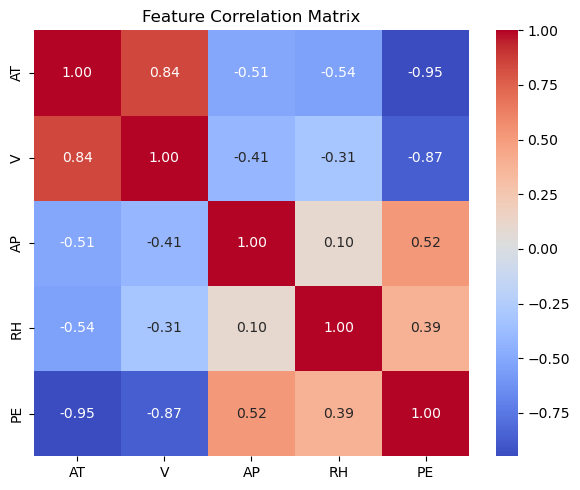

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

 2. Features & Target

In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

3. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (7654, 4)  Test: (1914, 4)


 4. Results Tracker



In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

results = {}

def evaluate(name, y_true, y_pred, cv_score=None):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results[name] = {
        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse,
        'CV R2 (mean)': cv_score
    }
    cv_text = f", CV R2: {cv_score:.4f}" if cv_score is not None else ""
    print(f"{name} -> R2: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}{cv_text}")

---
Model 1 — Linear Regression



In [7]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2').mean()
evaluate('Linear Regression', y_test, y_pred, cv)

Linear Regression -> R2: 0.9325, MAE: 3.5666, RMSE: 4.4423, CV R2: 0.9285


 Model 2 — Polynomial Regression



In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred = poly_reg.predict(X_test_poly)

cv = cross_val_score(LinearRegression(), X_poly, y, cv=5, scoring='r2').mean()
evaluate('Polynomial Regression', y_test, y_pred, cv)

Polynomial Regression -> R2: 0.9455, MAE: 3.1434, RMSE: 3.9916, CV R2: 0.9416


---
 Model 3 — Support Vector Regression (SVR)


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_sc = sc_X.fit_transform(X_train)
y_train_sc = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()

svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train_sc, y_train_sc)

y_pred_sc = svr_reg.predict(sc_X.transform(X_test))
y_pred = sc_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()

evaluate('SVR', y_test, y_pred)

SVR -> R2: 0.9481, MAE: 2.9952, RMSE: 3.8970


---
 Model 4 — Decision Tree Regression



In [10]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=0)
tree_reg.fit(X_train, y_train)
y_pred = tree_reg.predict(X_test)

cv = cross_val_score(DecisionTreeRegressor(random_state=0), X, y, cv=5, scoring='r2').mean()
evaluate('Decision Tree', y_test, y_pred, cv)

Decision Tree -> R2: 0.9229, MAE: 3.1039, RMSE: 4.7486, CV R2: 0.9286


---
 Model 5 — Random Forest Regression



In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=0)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

cv = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=0), X, y, cv=5, scoring='r2').mean()
evaluate('Random Forest', y_test, y_pred, cv)

Random Forest -> R2: 0.9651, MAE: 2.3458, RMSE: 3.1944, CV R2: 0.9618


---
 Model 6 — K-Nearest Neighbors Regression



In [16]:
from sklearn.neighbors import KNeighborsRegressor

sc_X_knn = StandardScaler()
X_train_knn = sc_X_knn.fit_transform(X_train)
X_test_knn = sc_X_knn.transform(X_test)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_knn, y_train)
y_pred = knn_reg.predict(X_test_knn)

evaluate('KNN', y_test, y_pred)

KNN -> R2: 0.9541, MAE: 2.7253, RMSE: 3.6656


 Final Comparison

All six regression models side by side, sorted by test-set R² (highest first).

In [13]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2 Score', ascending=False)
results_df

,R2 Score,MAE,RMSE,CV R2 (mean)
Random Forest,0.965113,2.345760,3.194351,0.961835
KNN,0.954060,2.725254,3.665640,NaN
SVR,0.948078,2.995178,3.896978,NaN
Polynomial Regression,0.945526,3.143431,3.991608,0.941635
Linear Regression,0.932532,3.566565,4.442263,0.928538
Decision Tree,0.922906,3.103924,4.748589,0.928626


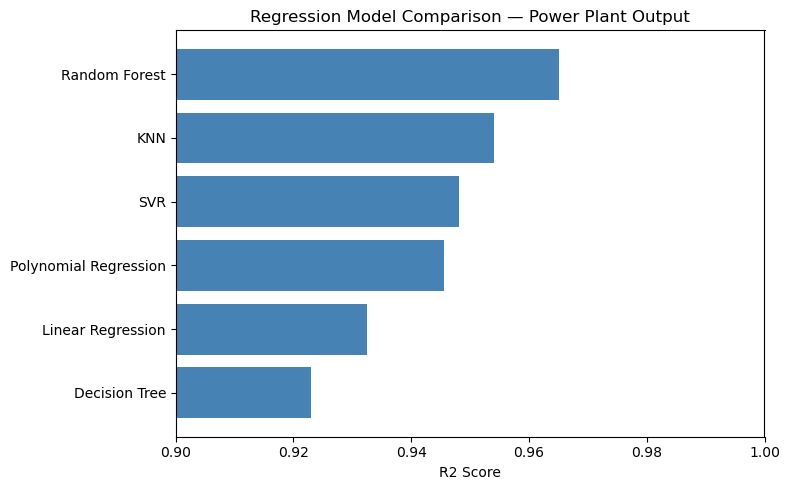

In [14]:
plt.figure(figsize=(8, 5))
plt.barh(results_df.index, results_df['R2 Score'], color='steelblue')
plt.xlabel('R2 Score')
plt.title('Regression Model Comparison — Power Plant Output')
plt.xlim(min(0.9, results_df['R2 Score'].min() - 0.02), 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()